In [1]:
try:
    import plotly, skrub
    from mlxtend.feature_selection import SequentialFeatureSelector
    from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
except:
    %pip install -qq plotly mlxtend skrub
    import plotly, skrub
    from mlxtend.feature_selection import SequentialFeatureSelector
    from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

Note: you may need to restart the kernel to use updated packages.


In [2]:
## -- Device-Agnostic for GPU --
import torch
print(f"ℹ️ Running on Cuda: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    get_ipython().run_line_magic('load_ext', 'cuml.accel')
    from cuml.preprocessing import TargetEncoder as cuTE
else:
    pass

ℹ️ Running on Cuda: False


In [3]:
## -- System dependencies --
import sys, os, gc

## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
from itertools import combinations, product

## -- Machine Learning --
import sklearn
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_squared_error, PredictionErrorDisplay

import warnings

In [4]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
plt.style.use("ggplot")
# sns.set_style("whitegrid")
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
PALETTE = ['c', 'r', 'orange']

## -- Set Global Seed --
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

COLOR = '\033[32m'
RESET = '\033[0m'

In [5]:
### Load Data ###
PATH = '/kaggle/input/playground-series-s6e1/'
submit = pd.read_csv(PATH+'sample_submission.csv')
train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)

TARGET = train.columns[-1]
NUMS = test.select_dtypes(include='number').columns.tolist()
CATS = test.select_dtypes(exclude='number').columns.tolist()
BASE = NUMS + CATS

orig = pd.read_csv('/kaggle/input/exam-score-prediction-dataset/Exam_Score_Prediction.csv'
                  ).drop('student_id', axis=1)

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (630000, 12)
Test shape: (270000, 11)
Original shape: (20000, 12)

Total Numerical: 4
Total Categorical: 7
Total base features: 11


In [6]:
display(train.head())
train.info()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   age               630000 non-null  int64  
 1   gender            630000 non-null  str    
 2   course            630000 non-null  str    
 3   study_hours       630000 non-null  float64
 4   class_attendance  630000 non-null  float64
 5   internet_access   630000 non-null  str    
 6   sleep_hours       630000 non-null  float64
 7   sleep_quality     630000 non-null  str    
 8   study_method      630000 non-null  str    
 9   facility_rating   630000 non-null  str    
 10  exam_difficulty   630000 non-null  str    
 11  exam_score        630000 non-null  float64
dtypes: float64(4), int64(1), str(7)
memory usage: 80.0 MB


In [7]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient(cmap='bone')

,age,study_hours,class_attendance,sleep_hours,gender,course,internet_access,sleep_quality,study_method,facility_rating,exam_difficulty
Train,8,792,617,66,3,7,2,3,5,3,3
Original,8,784,589,59,3,7,2,3,5,3,3
Test,8,786,604,64,3,7,2,3,5,3,3


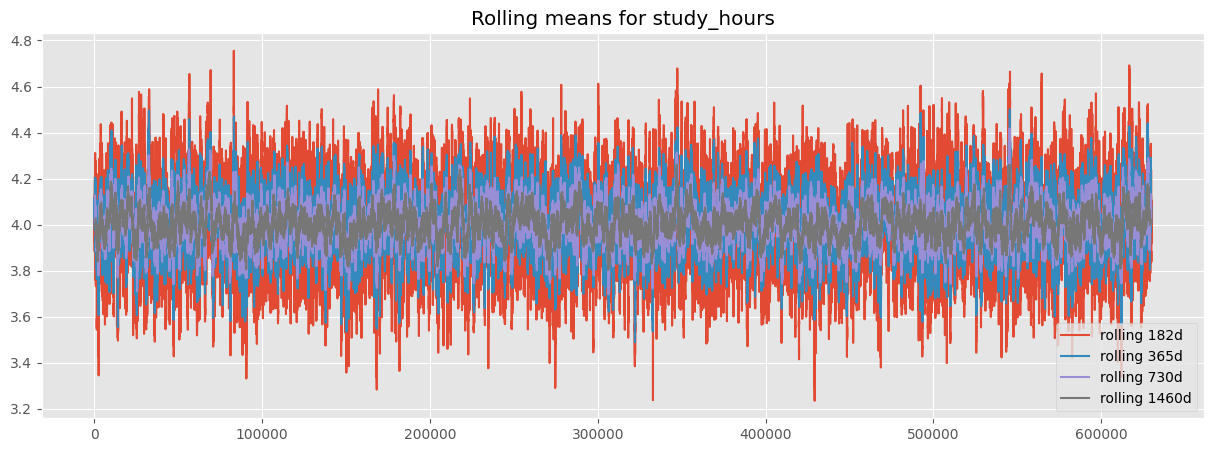

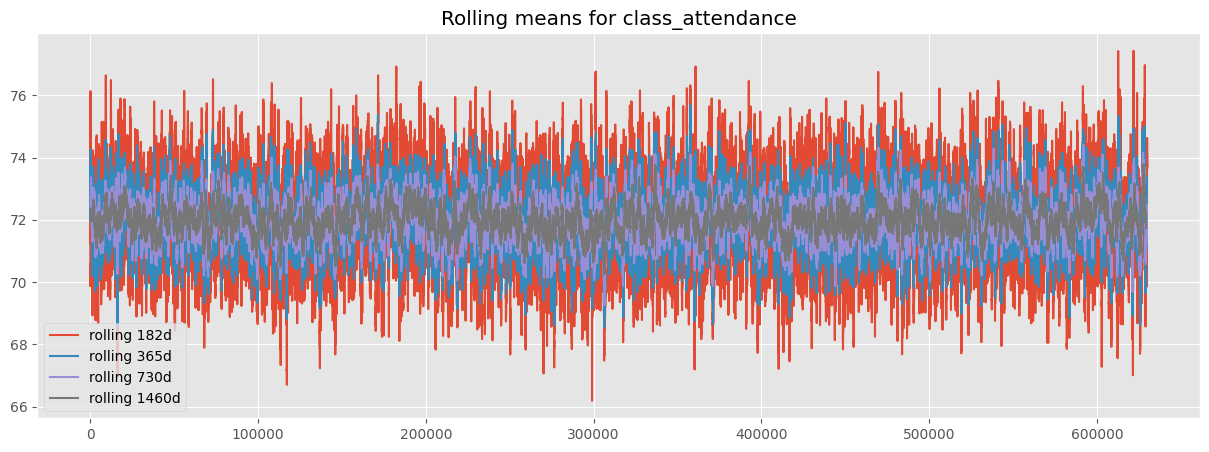

In [8]:
windows = [365//2, 365, 365*2, 365*4]
plt.figure(figsize=(15, 5))
for w in windows:
    plt.plot(train.index, train['study_hours'].rolling(window=w, center=True).mean(), label=f'rolling {w}d')
plt.legend()
plt.title('Rolling means for study_hours')
plt.show()

plt.figure(figsize=(15, 5))
for w in windows:
    plt.plot(train.index, train['class_attendance'].rolling(window=w, center=True).mean(), label=f'rolling {w}d')
plt.legend()
plt.title('Rolling means for class_attendance')
plt.show()

## FEATURE ENGINEERING

In [9]:
# ## -- meta feature --
# for df in [train, test, orig]:
#     base_risk = (
#         5.88 * df["study_hours"] + \
#         0.34 * df["class_attendance"] + \
#         # 1.44 * (df["sleep_quality"] == 'good').astype(int) + \
#         15.2
#             )
#     df['meta'] = base_risk

# BASE.append("meta")
# print(f"√'base_score' feature created")

# display(train.head())
# sns.histplot(train['meta'])

In [10]:
def feature_preprocess(df):
    df_temp = df.copy()

    df_temp['study_hours_squared'] = df_temp['study_hours'] ** 2
    df_temp['study_hours_cubed'] = df_temp['study_hours'] ** 3
    df_temp['class_attendance_squared'] = df_temp['class_attendance'] ** 2
    df_temp['sleep_hours_squared'] = df_temp['sleep_hours'] ** 2
    df_temp['age_squared'] = df_temp['age'] ** 2

    df_temp['log_study_hours'] = np.log1p(df_temp['study_hours'])
    df_temp['log_class_attendance'] = np.log1p(df_temp['class_attendance'])
    df_temp['log_sleep_hours'] = np.log1p(df_temp['sleep_hours'])
    df_temp['sqrt_study_hours'] = np.sqrt(df_temp['study_hours'])
    df_temp['sqrt_class_attendance'] = np.sqrt(df_temp['class_attendance'])

    # Interaction features
    df_temp['study_hours_times_attendance'] = df_temp['study_hours'] * df_temp['class_attendance']
    df_temp['study_hours_times_sleep'] = df_temp['study_hours'] * df_temp['sleep_hours']
    df_temp['attendance_times_sleep'] = df_temp['class_attendance'] * df_temp['sleep_hours']

    # Ratio features (add small epsilon to avoid division by zero)
    eps = 1e-6
    df_temp['study_hours_over_sleep'] = df_temp['study_hours'] / (df_temp['sleep_hours'] + eps)
    df_temp['attendance_over_sleep'] = df_temp['class_attendance'] / (df_temp['sleep_hours'] + eps)

    # Thanks to Vladimir Demidov for the following feature
    # https://www.kaggle.com/competitions/playground-series-s6e1/discussion/665915
    LUT = {
        'sleep_quality': {'good': 5, 'average': 0, 'poor': -5},
        'facility_rating': {'high': 4, 'medium': 0, 'low': -4},
        'study_method': {
            'coaching': 10,
            'mixed': 5,
            'group study': 2,
            'online videos': 1,
            'self-study': 0
        }
    }

    df_temp['formula'] = 6.0 * df_temp['study_hours'] + 0.35 * df_temp['class_attendance'] \
            + 1.5 * df_temp['sleep_hours'] + \
            + df_temp['sleep_quality'].map(LUT['sleep_quality']) \
            + df_temp['study_method'].map(LUT['study_method']) \
            + df_temp['facility_rating'].map(LUT['facility_rating'])

    # Encode categorical variables to numeric ordinal values
    ordinal_maps = {
        "internet_access": {"no":0, "yes":1},
        "gender": {"male":0, "female":1, "other":2},
        "sleep_quality": {"poor":0, "average":1, "good":2},
        "facility_rating": {"low":0, "medium":1, "high":2},
        "exam_difficulty": {"easy":0, "moderate":1, "hard":2},
        "course": {"ba":0, "b.sc":1, "diploma":2, "b.tech":3, "b.com":4, "bca":5, "bba":6},
        "study_method": {"self-study":0, "online videos":1, "group study":2, "mixed":3, "coaching":4},
    }

    for c in CATS:
        df_temp[c] = df_temp[c].map(ordinal_maps[c]).fillna(-1)

    # Interaction between encoded categoricals and key numeric features
    df_temp['study_hours_times_sleep_quality'] = df_temp['study_hours'] * df_temp['sleep_quality']
    df_temp['attendance_times_facility'] = df_temp['class_attendance'] * df_temp['facility_rating']
    df_temp['sleep_hours_times_difficulty'] = df_temp['sleep_hours'] * df_temp['exam_difficulty']
    df_temp['age_times_study_hours'] = df_temp['age'] * df_temp['study_hours']
    df_temp['age_times_attendance'] = df_temp['age'] * df_temp['class_attendance']

    # Composite feature: learning efficiency
    df_temp['efficiency'] = (df_temp['study_hours'] * df_temp['class_attendance']) / (df_temp['sleep_hours'] + 1)
    df_temp["study_efficiency"] = df_temp["study_hours"] * (df_temp["class_attendance"] / 100.0)

    # Cyclic encoding
    for p in [12, 14, 365//2, 365, 365*2, 365*4]:
        df_temp[f"study_hours_sin_{p}"] = np.sin(2 * np.pi * df_temp['study_hours'] / p)
        df_temp[f"class_attendance_sin_{p}"] = np.sin(2 * np.pi * df_temp['class_attendance'] / p)

    total_features = [c for c in df_temp.columns if c != TARGET]
    print(f'Feature Engineered: {len(total_features)}')

    return df_temp # [base_features + numeric_features]

lr_train = feature_preprocess(train)
lr_test = feature_preprocess(test)
lr_orig = feature_preprocess(orig)

Feature Engineered: 46


Feature Engineered: 46
Feature Engineered: 46


In [11]:
# ## -- Factorize using combined data --
# for c in CATS:
#     combine  = pd.concat([train[c], test[c], orig[c]])
#     combine  = combine.factorize()[0]
#     train[c] = combine[:len(train)]
#     test[c]  = combine[len(train):len(train)+len(test)]
#     orig[c]  = combine[-len(orig):]

# NUMS.remove('age')
# CATS.append('age')

# print('Label encoding complete!')

In [12]:
# TOP_PREDICTORS = ['study_hours', 'class_attendance']
# OTHER_PREDICTORS = [c for c in BASE if c not in TOP_PREDICTORS]
# print('Feature sets defined!')

# for k, v in dict(age=45, sleep=9.4, classy=92.6, study=6.59).items():
#     print(f'{k} -----')
#     for i in [-2, -1, 0, 1]:
#         print(f'Round {v} to {i}: {np.round(v, i)}')

In [13]:
# ROUND = []
# for col in tqdm(TOP_PREDICTORS+['sleep_hours', 'age']):
#     for r in [-1, 0, 1]:
#         n = f"{col}_r{r}"
#         train[n] = train[col].round(r).astype('int8')
#         test[n] = test[col].round(r).astype('int8')
#         orig[n] = test[col].round(r).astype('int8')

#         ## -- Drop constant features --
#         if train[n].nunique() < 2:
#             train.drop([n], axis=1, inplace=True)
#             test.drop([n],  axis=1, inplace=True)
#             orig.drop([n],  axis=1, inplace=True)
#         else:
#             ROUND.append(n)

# print(f'{len(ROUND)} ROUND Features created.')
# print(train[ROUND].nunique())

In [14]:
# ## -- Extract Digits --
# DIGITS = []

# for col in tqdm(TOP_PREDICTORS+['sleep_hours']):
#     for d in range(-2, 4):
#         n = f'{col}_d{d}'
#         train[n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
#         test[n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
#         orig[n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')

#         ## -- Drop constant features --
#         if train[n].nunique() < 2:
#             train.drop([n], axis=1, inplace=True)
#             test.drop([n],  axis=1, inplace=True)
#             orig.drop([n],  axis=1, inplace=True)
#         else:
#             DIGITS.append(n)

# print(f'{len(DIGITS)} Feature DIGITS extracted.')
# print(train[DIGITS].nunique())

In [15]:
# INTER = []

# for c1, c2 in tqdm(list(combinations(TOP_PREDICTORS, 2)), desc='1-to-1 Pairwise'):
#     n_col = f"{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col] = test[c1].astype(str) + '_' + test[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(combinations(TOP_PREDICTORS+TOP_PREDICTORS_2, 3)), desc='Triplewise'):
# #     n_col = f"{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col] = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# for c1, c2 in tqdm(list(product(TOP_PREDICTORS, OTHER_PREDICTORS)), desc='1-to-many Pairwise'):
#     new_col = f"{c1}-|-{c2}"
#     train[new_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[new_col] = test[c1].astype(str) + '_' + test[c2].astype(str)
#     INTER.append(new_col)

# print(f"Interaction Features: {len(INTER)}")

In [16]:
# %%time
# ## -- Merging original features as columns --
# ORIG = []

# for col in tqdm(BASE): 
#     # MEAN
#     mean_col = f"OTE_{col}_mean"
#     mean_map = orig.groupby(col)[TARGET].mean().reset_index(name=mean_col)

#     train = train.merge(mean_map, on=col, how='left')
#     test = test.merge(mean_map, on=col, how='left')
#     ORIG.append(mean_col)

#     # COUNT
#     count_col = f"OTE_{col}_count"
#     count_map = orig.groupby(col).size().reset_index(name=count_col)

#     train = train.merge(count_map, on=col, how='left')
#     test = test.merge(count_map, on=col, how='left')
#     ORIG.append(count_col)

#     # # UNIQUE
#     # unique_col = f"OTE_{col}_nunique"
#     # unique_map = orig.groupby(col)[TARGET].nunique().reset_index(name=unique_col)

#     # train = train.merge(unique_map, on=col, how='left')
#     # test = test.merge(unique_map, on=col, how='left')
#     # ORIG.append(unique_col)

#     # STD
#     std_col = f"OTE_{col}_std"
#     std_map = orig.groupby(col)[TARGET].std().reset_index(name=std_col)

#     train = train.merge(std_map, on=col, how='left')
#     test = test.merge(std_map, on=col, how='left')
#     ORIG.append(std_col)

#     # MAX
#     max_col = f"OTE_{col}_max"
#     max_map = orig.groupby(col)[TARGET].max().reset_index(name=max_col)

#     train = train.merge(max_map, on=col, how='left')
#     test = test.merge(max_map, on=col, how='left')
#     ORIG.append(max_col)

#     # MIN
#     min_col = f"OTE_{col}_min"
#     min_map = orig.groupby(col)[TARGET].min().reset_index(name=min_col)

#     train = train.merge(min_map, on=col, how='left')
#     test = test.merge(min_map, on=col, how='left')
#     ORIG.append(min_col)

#     # MEDIAN
#     median_col = f"OTE_{col}_median"
#     median_map = orig.groupby(col)[TARGET].median().reset_index(name=median_col)

#     train = train.merge(median_map, on=col, how='left')
#     test = test.merge(median_map, on=col, how='left')
#     ORIG.append(median_col)
        
# # for col in ORIG:
# #     if train[col].nunique() < 2:
# #         train.drop([col], axis=1, inplace=True)
# #         test.drop([col], axis=1, inplace=True)
# #         ORIG.remove(col)
# #     else:
# #         continue

# print(len(ORIG), 'Orig Features Created!')

In [17]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         # Downcast Integer type
#         if df[c].dtype == np.int64: 
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         # Downcast Float type
#         elif df[c].dtype == np.float64: 
#             if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#                 df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")
    
#     return df

# lr_train = reduce_memory(lr_train)
# lr_test = reduce_memory(lr_test)
# lr_orig = reduce_memory(lr_orig)

# gc.collect()

# print(f"Data memory reduced!")

In [18]:
lr_train.head(3)

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,study_hours_squared,study_hours_cubed,class_attendance_squared,sleep_hours_squared,age_squared,log_study_hours,log_class_attendance,log_sleep_hours,sqrt_study_hours,sqrt_class_attendance,study_hours_times_attendance,study_hours_times_sleep,attendance_times_sleep,study_hours_over_sleep,attendance_over_sleep,formula,study_hours_times_sleep_quality,attendance_times_facility,sleep_hours_times_difficulty,age_times_study_hours,age_times_attendance,efficiency,study_efficiency,study_hours_sin_12,class_attendance_sin_12,study_hours_sin_14,class_attendance_sin_14,study_hours_sin_182,class_attendance_sin_182,study_hours_sin_365,class_attendance_sin_365,study_hours_sin_730,class_attendance_sin_730,study_hours_sin_1460,class_attendance_sin_1460
0,21,1,1,7.91,98.8,0,4.9,1,1,0,0,78.3,62.5681,494.913671,9761.44,24.01,441,2.187174,4.603168,1.774952,2.812472,9.939819,781.508,38.759,484.12,1.614285,20.163261,86.39,7.91,0.0,0.0,166.11,2074.8,132.458983,7.81508,-0.841511,0.994522,-0.397148,0.351375,0.269696,-0.266037,0.135744,0.991566,0.068030,0.751532,0.034035,0.412495
1,18,2,2,4.95,94.8,1,4.7,0,0,1,1,46.7,24.5025,121.287375,8987.04,22.09,324,1.783391,4.562263,1.740466,2.224860,9.736529,469.260,23.265,445.56,1.053191,20.170208,64.93,0.00,94.8,4.7,89.10,1706.4,82.326316,4.69260,0.522499,-0.587785,0.795625,-0.990950,0.170058,-0.130811,0.085107,0.998133,0.042592,0.728379,0.021301,0.396753
2,20,1,1,4.68,92.6,1,5.8,0,4,2,1,99.0,21.9024,102.503232,8574.76,33.64,400,1.736951,4.539030,1.916923,2.163331,9.622889,433.368,27.144,537.08,0.806896,15.965514,78.19,0.00,185.2,5.8,93.60,1852.0,63.730588,4.33368,0.637424,-0.978148,0.863018,-0.657939,0.160866,-0.055209,0.080475,0.999730,0.040270,0.715275,0.020139,0.388044


In [19]:
lr_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 47 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   age                              630000 non-null  int64  
 1   gender                           630000 non-null  int64  
 2   course                           630000 non-null  int64  
 3   study_hours                      630000 non-null  float64
 4   class_attendance                 630000 non-null  float64
 5   internet_access                  630000 non-null  int64  
 6   sleep_hours                      630000 non-null  float64
 7   sleep_quality                    630000 non-null  int64  
 8   study_method                     630000 non-null  int64  
 9   facility_rating                  630000 non-null  int64  
 10  exam_difficulty                  630000 non-null  int64  
 11  exam_score                       630000 non-null  float64
 12  study_hours_s

In [20]:
from sklearn.base import BaseEstimator, TransformerMixin

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique', 
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the 
        global mean. If 'auto', an empirical Bayes estimate is used.
        
    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping
        
        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
        
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)
        
        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]
            
            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'
                    
                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)
                    
                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()
                        
                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups
                        
                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)
                    
                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]
            
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed

# ML TRAINING

In [21]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

y = train[TARGET].values
y_min, y_max = min(y), max(y)
kf = KFold(n_splits=8, shuffle=True, random_state=SEED)

oof_final = pd.DataFrame()
test_final = pd.DataFrame()
model_score = pd.Series()

### ~ LINEAR MODELS

In [22]:
from sklearn.linear_model import (
            LinearRegression,
            ElasticNet,
            Lasso,
            Ridge,
            RidgeCV,
            Lars,
            LassoLars,
            BayesianRidge,
            ARDRegression,
            TheilSenRegressor,
            HuberRegressor,
            RANSACRegressor,
            OrthogonalMatchingPursuit,
            QuantileRegressor,
)
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

In [23]:
## -- Define Models --
linear_models = {
    'lr': LinearRegression(n_jobs=os.cpu_count()),
    'enet': ElasticNet(max_iter=1000, tol=1e-5, random_state=SEED),
    'lasso': Lasso(tol=1e-5, alpha=1e-1, random_state=SEED),
    'bayes': BayesianRidge(max_iter=1000, tol=1e-5),
    'ridge': Ridge(tol=1e-5, alpha=1e-1, random_state=SEED),
    # 'lassolars': LassoLars(max_iter=1000, random_state=SEED),
    # 'ard': ARDRegression(max_iter=1000, tol=1e-5),
    # 'huber': HuberRegressor(max_iter=1000, alpha=1e-1, tol=1e-5),
    # 'omp': OrthogonalMatchingPursuit(tol=1e-5),
    # 'tsen': TheilSenRegressor(
    #     max_iter=1000,
    #     max_subpopulation=5000.0,
    #     tol=1e-5,
    #     random_state=SEED,
    #     n_jobs=os.cpu_count(),
    # ),
    'mlp': MLPRegressor(max_iter=1000, alpha=1e-2, tol=1e-5, random_state=SEED),
    # 'knn': KNeighborsRegressor(n_jobs=os.cpu_count()),
    # 'lars': Lars(random_state=SEED),
    # 'quanreg': QuantileRegressor(solver='highs'),
    # 'ransac': RANSACRegressor(random_state=SEED),
}

print(f"Linear Models to train: {len(linear_models)} -> ", linear_models.keys())

Linear Models to train: 6 ->  dict_keys(['lr', 'enet', 'lasso', 'bayes', 'ridge', 'mlp'])


In [24]:
## -- Prepare data for feature selection --
x_1 = lr_train.drop([TARGET], axis=1)
o_1 = lr_orig.drop([TARGET], axis=1)
ohe = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False,
    drop='first',
).fit(x_1[CATS+['age']]).set_output(transform='pandas')

train_new = pd.concat([x_1.drop(CATS+['age'], axis=1), ohe.transform(x_1[CATS+['age']])], axis=1)
orig_new = pd.concat([o_1.drop(CATS+['age'], axis=1), ohe.transform(o_1[CATS+['age']])], axis=1)
test_new = pd.concat([lr_test.drop(CATS+['age'], axis=1), ohe.transform(lr_test[CATS+['age']])], axis=1)

len(train_new), len(test_new), len(orig_new)

(630000, 270000, 20000)

In [25]:
# from mlxtend.feature_selection import SequentialFeatureSelector
# from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

# scaler = StandardScaler().set_output(transform='pandas')
# x_sfs = scaler.fit_transform(train_new)

# sfs = SequentialFeatureSelector(
#     Ridge(tol=1e-5,  alpha=0.1, random_state=SEED),
#     scoring='neg_root_mean_squared_error',
#     k_features='best',
#     n_jobs=os.cpu_count(),
#     verbose=2,
# )

# sfs.fit(x_sfs, y)

# fig = plot_sfs(sfs.get_metric_dict(), kind='std_err')
# plt.title('Sequential Forward Selection (w. StdDev)')
# plt.grid()
# plt.show()

# len(sfs.k_feature_names_), sfs.k_feature_names_

In [26]:
sfs_features = [
    'study_hours',
    'class_attendance',
    'sleep_hours',
    'study_hours_squared',
    'study_hours_cubed',
    'class_attendance_squared',
    'sleep_hours_squared',
    'age_squared',
    'log_study_hours',
    'log_class_attendance',
    'log_sleep_hours',
    'sqrt_study_hours',
    'sqrt_class_attendance',
    'study_hours_times_attendance',
    'study_hours_times_sleep',
    'attendance_times_sleep',
    'study_hours_over_sleep',
    'attendance_over_sleep',
    'formula',
    'study_hours_times_sleep_quality',
    'attendance_times_facility',
    'age_times_study_hours',
    'age_times_attendance',
    'efficiency',
    'study_efficiency',
    'study_hours_sin_12',
    'class_attendance_sin_12',
    'study_hours_sin_14',
    'class_attendance_sin_14',
    'study_hours_sin_182',
    'study_hours_sin_365',
    'class_attendance_sin_365',
    'study_hours_sin_730',
    'class_attendance_sin_730',
    'study_hours_sin_1460',
    'class_attendance_sin_1460',
    'gender_1',
    'gender_2',
    'course_1',
    'course_2',
    'course_3',
    'course_4',
    'course_5',
    'course_6',
    'sleep_quality_1',
    'sleep_quality_2',
    'study_method_1',
    'study_method_2',
    'study_method_3',
    'study_method_4',
    'facility_rating_1',
    'age_18',
    'age_19',
    'age_20',
    'age_21',
    'age_22',
    'age_23',
    'age_24',
]

# sfs_features = list(sfs.k_feature_names_)
sfs_features

['study_hours',
 'class_attendance',
 'sleep_hours',
 'study_hours_squared',
 'study_hours_cubed',
 'class_attendance_squared',
 'sleep_hours_squared',
 'age_squared',
 'log_study_hours',
 'log_class_attendance',
 'log_sleep_hours',
 'sqrt_study_hours',
 'sqrt_class_attendance',
 'study_hours_times_attendance',
 'study_hours_times_sleep',
 'attendance_times_sleep',
 'study_hours_over_sleep',
 'attendance_over_sleep',
 'formula',
 'study_hours_times_sleep_quality',
 'attendance_times_facility',
 'age_times_study_hours',
 'age_times_attendance',
 'efficiency',
 'study_efficiency',
 'study_hours_sin_12',
 'class_attendance_sin_12',
 'study_hours_sin_14',
 'class_attendance_sin_14',
 'study_hours_sin_182',
 'study_hours_sin_365',
 'class_attendance_sin_365',
 'study_hours_sin_730',
 'class_attendance_sin_730',
 'study_hours_sin_1460',
 'class_attendance_sin_1460',
 'gender_1',
 'gender_2',
 'course_1',
 'course_2',
 'course_3',
 'course_4',
 'course_5',
 'course_6',
 'sleep_quality_1',
 's

In [27]:
train_new.head(3)

,study_hours,class_attendance,sleep_hours,study_hours_squared,study_hours_cubed,class_attendance_squared,sleep_hours_squared,age_squared,log_study_hours,log_class_attendance,log_sleep_hours,sqrt_study_hours,sqrt_class_attendance,study_hours_times_attendance,study_hours_times_sleep,attendance_times_sleep,study_hours_over_sleep,attendance_over_sleep,formula,study_hours_times_sleep_quality,attendance_times_facility,sleep_hours_times_difficulty,age_times_study_hours,age_times_attendance,efficiency,study_efficiency,study_hours_sin_12,class_attendance_sin_12,study_hours_sin_14,class_attendance_sin_14,study_hours_sin_182,class_attendance_sin_182,study_hours_sin_365,class_attendance_sin_365,study_hours_sin_730,class_attendance_sin_730,study_hours_sin_1460,class_attendance_sin_1460,gender_1,gender_2,course_1,course_2,course_3,course_4,course_5,course_6,internet_access_1,sleep_quality_1,sleep_quality_2,study_method_1,study_method_2,study_method_3,study_method_4,facility_rating_1,facility_rating_2,exam_difficulty_1,exam_difficulty_2,age_18,age_19,age_20,age_21,age_22,age_23,age_24
0,7.91,98.8,4.9,62.5681,494.913671,9761.44,24.01,441,2.187174,4.603168,1.774952,2.812472,9.939819,781.508,38.759,484.12,1.614285,20.163261,86.39,7.91,0.0,0.0,166.11,2074.8,132.458983,7.81508,-0.841511,0.994522,-0.397148,0.351375,0.269696,-0.266037,0.135744,0.991566,0.068030,0.751532,0.034035,0.412495,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,4.95,94.8,4.7,24.5025,121.287375,8987.04,22.09,324,1.783391,4.562263,1.740466,2.224860,9.736529,469.260,23.265,445.56,1.053191,20.170208,64.93,0.00,94.8,4.7,89.10,1706.4,82.326316,4.69260,0.522499,-0.587785,0.795625,-0.990950,0.170058,-0.130811,0.085107,0.998133,0.042592,0.728379,0.021301,0.396753,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.68,92.6,5.8,21.9024,102.503232,8574.76,33.64,400,1.736951,4.539030,1.916923,2.163331,9.622889,433.368,27.144,537.08,0.806896,15.965514,78.19,0.00,185.2,5.8,93.60,1852.0,63.730588,4.33368,0.637424,-0.978148,0.863018,-0.657939,0.160866,-0.055209,0.080475,0.999730,0.040270,0.715275,0.020139,0.388044,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [28]:
## -- Initiate Training -- 
lr_X = train_new[sfs_features]
LINEAR_MODELS = {}

for i, (name, model) in tqdm(
    enumerate(linear_models.items()),
    total=len(linear_models),
    desc='Training Models.'
):
    print(f"\n[{i+1}] {COLOR}{name} {'#'*10}{RESET}")
    tik = time()

    oof_preds  = np.zeros(len(lr_X))
    test_preds = np.zeros(len(lr_test))
    fold_RMSEs = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(lr_X)):
        X_train, X_val = lr_X.iloc[train_idx], lr_X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        X_test = test_new[sfs_features].copy()

        ## -- Concatenate original data --
        X_train_merged = pd.concat([X_train, orig_new[sfs_features]], ignore_index=True)
        y_train_merged = np.concatenate([y_train, lr_orig[TARGET].values], axis=0)

        ## -- Create pipeline --
        lr_model = make_pipeline(
            # make_column_transformer(
            #     (OneHotEncoder(
            #         handle_unknown='ignore',
            #         # sparse_output=False,
            #         drop='first',
            #     ), CATS+['age']),
            #     remainder='passthrough',
            #     n_jobs=os.cpu_count(),
            # ),
            StandardScaler(), #with_mean=False
            model,
        )
        lr_model.fit(X_train_merged, y_train_merged)
        y_pred = lr_model.predict(X_val)
        oof_preds[val_idx] = y_pred

        # Predict on test set (accumulate final prediction)
        predictions = lr_model.predict(X_test)
        test_preds += predictions / kf.n_splits

        # Compute RMSE for validation fold
        fold_rmse = np.round(rmse(y_val, y_pred), 5)
        fold_RMSEs.append(fold_rmse)

        print(f"\tFold {fold+1} RMSE: {fold_rmse}")

    ## -- After all folds --
    overall_RMSE = np.round(rmse(y, oof_preds), 5)
    print(f"|{'-'*52}")
    print(f"| OOF RMSE: {overall_RMSE}")
    print(f"| AVG RMSE: {np.mean(fold_RMSEs):.5f} ± {np.std(fold_RMSEs):.5f}")

    oof_final[name] = oof_preds
    test_final[name] = test_preds
    LINEAR_MODELS[name] = lr_model
    model_score[name] = overall_RMSE

    tok = time()
    tiktok = tok-tik
    print(f"| Duration: {tiktok:.2f} secs")

    gc.collect()

Training Models.:   0%|          | 0/6 [00:00<?, ?it/s]


[1] lr ##########


	Fold 1 RMSE: 8.84081


	Fold 2 RMSE: 8.89449


	Fold 3 RMSE: 8.89127


...

	Fold 4 RMSE: 8.85044


	Fold 5 RMSE: 8.86227


	Fold 6 RMSE: 8.90186


	Fold 7 RMSE: 8.8934


	Fold 8 RMSE: 8.89816
|----------------------------------------------------
| OOF RMSE: 8.8782
| AVG RMSE: 8.87817 ± 0.01908
| Duration: 1932.16 secs


In [29]:
model_score.sort_values()

mlp      8.87820
lr       8.87889
ridge    8.88068
bayes    8.88088
lasso    8.89779
enet     9.35014
dtype: float64

### ~ TREE MODELS

In [30]:
## -- TREE MODELS --
from sklearn.ensemble import (
            RandomForestRegressor,
            AdaBoostRegressor,
            BaggingRegressor,
            ExtraTreesRegressor,
            HistGradientBoostingRegressor,
            IsolationForest,
)

In [31]:
gb_train = feature_preprocess(train)
gb_test = feature_preprocess(test)
gb_orig = feature_preprocess(orig)

Feature Engineered: 46


Feature Engineered: 46
Feature Engineered: 46


In [32]:
gb_train.head(3)

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,study_hours_squared,study_hours_cubed,class_attendance_squared,sleep_hours_squared,age_squared,log_study_hours,log_class_attendance,log_sleep_hours,sqrt_study_hours,sqrt_class_attendance,study_hours_times_attendance,study_hours_times_sleep,attendance_times_sleep,study_hours_over_sleep,attendance_over_sleep,formula,study_hours_times_sleep_quality,attendance_times_facility,sleep_hours_times_difficulty,age_times_study_hours,age_times_attendance,efficiency,study_efficiency,study_hours_sin_12,class_attendance_sin_12,study_hours_sin_14,class_attendance_sin_14,study_hours_sin_182,class_attendance_sin_182,study_hours_sin_365,class_attendance_sin_365,study_hours_sin_730,class_attendance_sin_730,study_hours_sin_1460,class_attendance_sin_1460
0,21,1,1,7.91,98.8,0,4.9,1,1,0,0,78.3,62.5681,494.913671,9761.44,24.01,441,2.187174,4.603168,1.774952,2.812472,9.939819,781.508,38.759,484.12,1.614285,20.163261,86.39,7.91,0.0,0.0,166.11,2074.8,132.458983,7.81508,-0.841511,0.994522,-0.397148,0.351375,0.269696,-0.266037,0.135744,0.991566,0.068030,0.751532,0.034035,0.412495
1,18,2,2,4.95,94.8,1,4.7,0,0,1,1,46.7,24.5025,121.287375,8987.04,22.09,324,1.783391,4.562263,1.740466,2.224860,9.736529,469.260,23.265,445.56,1.053191,20.170208,64.93,0.00,94.8,4.7,89.10,1706.4,82.326316,4.69260,0.522499,-0.587785,0.795625,-0.990950,0.170058,-0.130811,0.085107,0.998133,0.042592,0.728379,0.021301,0.396753
2,20,1,1,4.68,92.6,1,5.8,0,4,2,1,99.0,21.9024,102.503232,8574.76,33.64,400,1.736951,4.539030,1.916923,2.163331,9.622889,433.368,27.144,537.08,0.806896,15.965514,78.19,0.00,185.2,5.8,93.60,1852.0,63.730588,4.33368,0.637424,-0.978148,0.863018,-0.657939,0.160866,-0.055209,0.080475,0.999730,0.040270,0.715275,0.020139,0.388044


In [33]:
tree_models = {
    'sk_rf': RandomForestRegressor(
        n_estimators=100,
        random_state=SEED,
        n_jobs=os.cpu_count(),
    ),
    # 'sk_ada': AdaBoostRegressor(
    #     # estimator = RandomForestRegressor(),
    #     n_estimators=100,
    #     learning_rate=0.1,
    #     random_state=SEED,
    # ),
    'sk_bag': BaggingRegressor(
        # estimator = RandomForestRegressor(),
        n_estimators=100,
        n_jobs=os.cpu_count(),
        random_state=SEED,
    ),
    'sk_xtra': ExtraTreesRegressor(
        n_estimators=100,
        min_samples_leaf=20,
        n_jobs=os.cpu_count(),
        random_state=SEED,
    ),
    'sk_hist': HistGradientBoostingRegressor(
        # n_estimators=20,
        learning_rate=0.01,
        max_iter = 1000,
        # l2_regularization=1e-3,
        random_state=SEED,
        categorical_features=CATS,
        scoring='neg_mean_squared_error',
        n_iter_no_change=20,
    ),
}

print(f"Tree Models to train: {len(tree_models)} -> ", end="")
print(list(tree_models.keys()))

Tree Models to train: 4 -> ['sk_rf', 'sk_bag', 'sk_xtra', 'sk_hist']


In [34]:
## -- Initiate Training -- 
FEATURES = [c for c in gb_train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

X = gb_train[FEATURES]
TREE_MODELS = {}

for i, (name, model) in tqdm(
    enumerate(tree_models.items()),
    total=len(tree_models),
    desc='Training Models.'
):
    print(f"\n[{i+1}] {COLOR}{name} {'#'*5}{RESET}")
    tik = time()

    oof_preds  = np.zeros(len(X))
    test_preds = np.zeros(len(test_new))
    fold_RMSEs = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        X_test = gb_test[FEATURES].copy()

        ## -- Concatenate original data --
        X_train = pd.concat([X_train, gb_orig[FEATURES]], ignore_index=True)
        y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        for c in CATS:
            X_train[c] = X_train[c].astype('category')
            X_val[c]   = pd.Categorical(X_val[c], categories=X_train[c].cat.categories)
            X_test[c]  = pd.Categorical(X_test[c], categories=X_train[c].cat.categories)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        oof_preds[val_idx] = y_pred

        ## -- Compute and save RMSE for val fold --
        fold_rmse = np.round(rmse(y_val, y_pred), 5)
        fold_RMSEs.append(fold_rmse)

        ## -- Predict on test set --
        predictions = model.predict(X_test)
        test_preds += predictions / kf.n_splits

        print(f"Fold {fold+1}/{kf.n_splits} RMSE: {fold_rmse}")

    tok = time()
    tiktok = tok-tik

    ## -- After all folds --
    oof_final[name] = oof_preds
    test_final[name] = test_preds
    TREE_MODELS[name] = model

    overall_RMSE = np.round(rmse(y, oof_preds), 5)
    model_score[name] = overall_RMSE

    print(f"|{'-'*52}")
    print(f"| OOF RMSE: {overall_RMSE}")
    print(f"| AVG RMSE: {np.mean(fold_RMSEs):.5f} ± {np.std(fold_RMSEs):.5f}")
    print(f"| Duration: {tiktok:.2f} secs")

    # ## -- Plot residuals --
    # fig, axs = plt.subplots(1, 2, figsize=(18, 5))
    # display = PredictionErrorDisplay.from_predictions(
    #     y, oof_preds, subsample=5000, ax=axs[0],
    #     # kind="actual_vs_predicted",
    #     scatter_kwargs={'alpha': 0.5},
    #     line_kwargs={'color': 'r'},
    # )
    # axs[0].set_title(f"Scatter Plot - {name}")
    # ## -----------------------------------------------------
    # sns.kdeplot(oof_preds, fill=True, ax=axs[1])
    # axs[1].set_title(f"Distribution Plot - {name}") 
    # ## -----------------------------------------------------
    # for ax in axs: ax.grid(False)
    # fig.tight_layout(pad=1.5) 
    # plt.show()

Total Features: 46


Training Models.:   0%|          | 0/4 [00:00<?, ?it/s]


[1] sk_rf #####


Fold 1/8 RMSE: 8.90915


Fold 2/8 RMSE: 8.95176


...

Fold 4/8 RMSE: 8.75498


Fold 5/8 RMSE: 8.77033


Fold 6/8 RMSE: 8.80737


Fold 7/8 RMSE: 8.79959


Fold 8/8 RMSE: 8.79627
|----------------------------------------------------
| OOF RMSE: 8.78339
| AVG RMSE: 8.78336 ± 0.02217
| Duration: 140.95 secs


<Axes: >

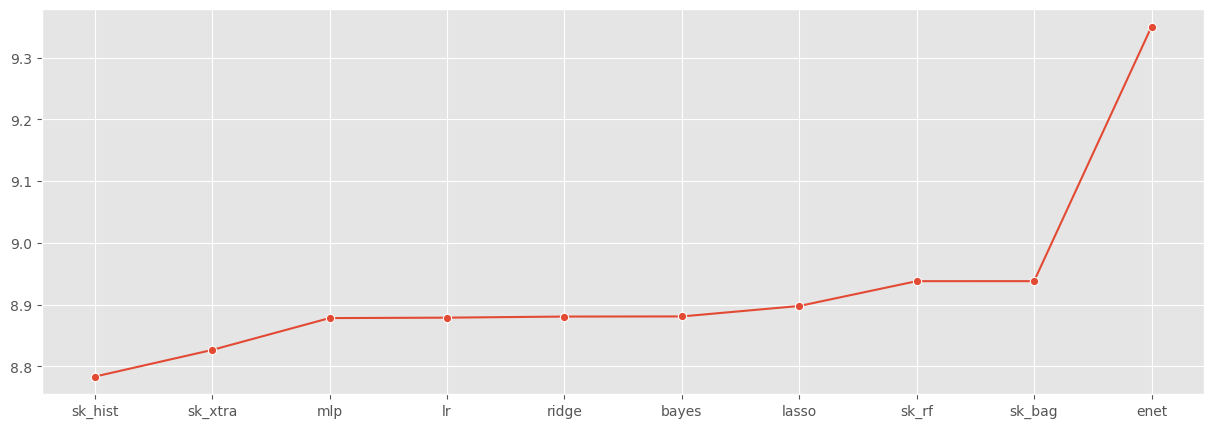

In [35]:
plt.figure(figsize=(15, 5))
sns.lineplot(model_score.sort_values(), marker='o')

## ~ STACKING


- Fold 1/8 - 

Stack RMSE: 8.72892

- Fold 2/8 - 

Stack RMSE: 8.77977

- Fold 3/8 - 

Stack RMSE: 8.78062

- Fold 4/8 - 

Stack RMSE: 8.73755

- Fold 5/8 - 

Stack RMSE: 8.75515

- Fold 6/8 - 

Stack RMSE: 8.79613

- Fold 7/8 - 

Stack RMSE: 8.78307

- Fold 8/8 - 

Stack RMSE: 8.78103
|--------------------------------------------------
| FEATURES: 10
| OOF RMSE: 8.76781
| AVG RMSE: 8.76778 ± 0.02265


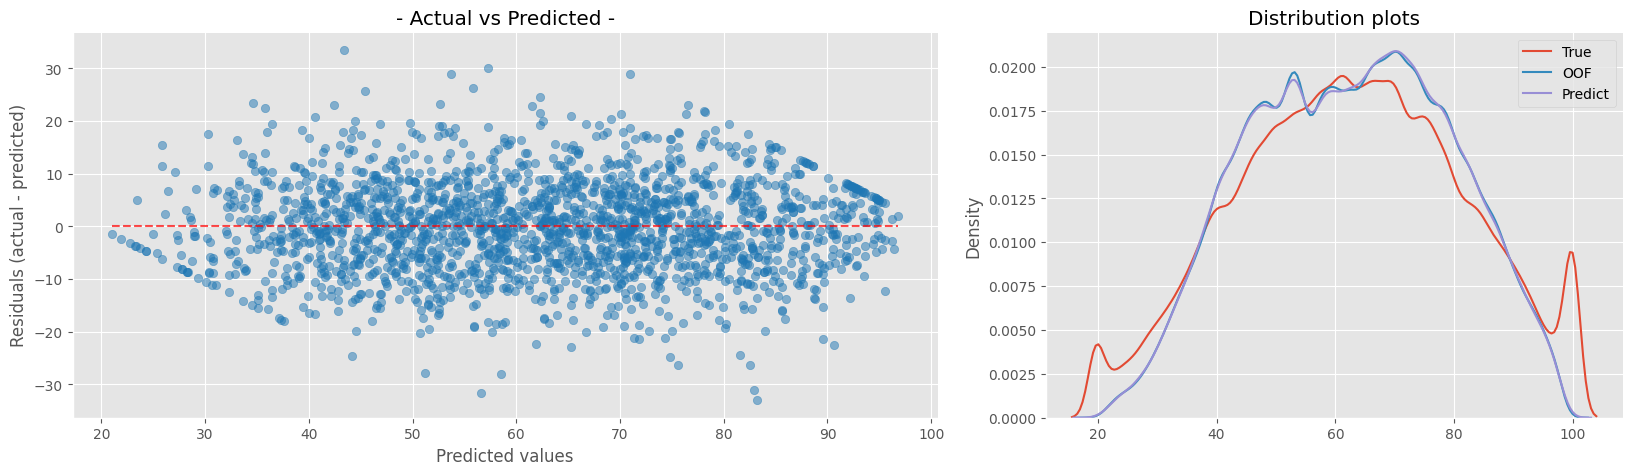

Training Time: 0.24 mins =========================


In [36]:
## -- Define Training Parameters --
stack_oof_preds  = np.zeros(len(oof_final))
stack_test_preds = np.zeros(len(test_final))
fold_scores = []

## -- Split data --
X = oof_final
y = train[TARGET].values

## -- Initiate Training --
tik = time()
for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\n- Fold {fold+1}/{kf.n_splits} - ", end='')
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    X_test = test_final.copy()

    for c in oof_final.columns:
        scaler = StandardScaler()
        X_train[c] = scaler.fit_transform(X_train[[c]], y_train)
        X_val[c]   = scaler.transform(X_val[[c]])
        X_test[c]  = scaler.transform(X_test[[c]])
        
    # meta_model = Ridge(tol=1e-5, random_state=SEED).fit(X_train, y_train)
    meta_model = RidgeCV(
        cv=5,
        alphas = (0.01, 0.1, 1.0, 10.0, 100.0),
        scoring='neg_mean_squared_error',
    ).fit(X_train, y_train)

    stack_y_pred = meta_model.predict(X_val)
    stack_oof_preds[val_idx] = stack_y_pred
    
    score = rmse(y_val, stack_y_pred)
    fold_scores.append(score)
    
    predictions = meta_model.predict(X_test)
    stack_test_preds += predictions / kf.n_splits

    print(f"Stack RMSE: {score:.5f}")

## -- After all folds --
stack_score = np.round(rmse(y, stack_oof_preds), 5)
stack_name  = 'ridge_stack' + stack_score.astype(str).split('.')[1]

oof_final[stack_name] = stack_oof_preds
test_final[stack_name] = stack_test_preds
model_score[stack_name] = stack_score

print(f"|{'-'*50}{COLOR}")
print(f"| FEATURES: {len(X_train.columns)}")
print(f"| OOF RMSE: {stack_score}")
print(f"| AVG RMSE: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}{RESET}")

## -- Plot predictions errors --
_, axs = plt.subplots(1, 2, figsize=(20, 5), gridspec_kw={'width_ratios':[0.6, 0.4], 'wspace':0.15})
display = PredictionErrorDisplay.from_predictions(
    y,
    stack_oof_preds,
    ax=axs[0], subsample=2000,
    # kind = "actual_vs_predicted",
    scatter_kwargs={'alpha': 0.5}, line_kwargs={'color': 'r'},
        )
axs[0].set_title(f"- Actual vs Predicted -")

LABELS = ['True', 'OOF', 'Predict']
sns.kdeplot(y, ax=axs[1], label=LABELS[0])
sns.kdeplot(oof_preds, ax=axs[1], label=LABELS[1])
sns.kdeplot(test_preds, ax=axs[1], label=LABELS[2])
axs[1].set_title(f"Distribution plots")

for ax in axs:
    # ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.legend()
plt.tight_layout()
plt.show()

tok = time()
tiktok = (tok-tik) / 60
print(f"Training Time: {tiktok:.2f} mins {'='*25}")

## ~ HILLCLIMB

In [37]:
%%time
try:
    from hillclimbers import climb_hill, partial
except:
    !pip install -q -U hillclimbers
    from hillclimbers import climb_hill, partial

## -- Run hillclimber --
hc_test_preds, hc_oof_preds = climb_hill(
        train=train,
        target=TARGET,
        oof_pred_df=oof_final.drop([stack_name], axis=1),
        test_pred_df=test_final.drop([stack_name], axis=1),
        eval_metric=partial(rmse),
        objective="minimize",
        precision=0.001,
        negative_weights=True,
        plot_hill=True,
        plot_hist=False,
        return_oof_preds=True
)


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


   /\  
  /__\  hillclimbers 
 /    \
/______\ 

Models to be ensembled | (10 total): 

sk_hist: 8.78339 (best solo model)
sk_xtra: 8.82659
mlp:     8.87820
lr:      8.87889
ridge:   8.88068
bayes:   8.88088
lasso:   8.89779
sk_rf:   8.93799
sk_bag:  8.93800
enet:    9.35014

[Data preparation completed successfully] - [Initiate hill climbing] 



Iteration: 1 | Model added: lr | Best weight: -0.490 | Best rmse: 8.77173


Iteration: 2 | Model added: sk_xtra | Best weight: 0.155 | Best rmse: 8.76982


Iteration: 3 | Model added: lasso | Best weight: -0.110 | Best rmse: 8.76853


...

Iteration: 5 | Model added: mlp | Best weight: 0.024 | Best rmse: 8.76807


Iteration: 6 | Model added: enet | Best weight: -0.012 | Best rmse: 8.76798


Iteration: 7 | Model added: bayes | Best weight: 0.001 | Best rmse: 8.76798


Iteration: 8 | Model added: sk_rf | Best weight: 0.001 | Best rmse: 8.76798


CPU times: user 1min 55s, sys: 2.97 s, total: 1min 58s
Wall time: 2min 1s


In [38]:
hc_score = np.round(rmse(y, hc_oof_preds), 5)
hc_name = 'sk_hc' + hc_score.astype(str).split('.')[1]

oof_final[hc_name] = hc_oof_preds
test_final[hc_name] = hc_test_preds
model_score[hc_name] = hc_score
model_score.sort_values(inplace=True)
model_score

ridge_stack76781    8.76781
sk_hc76798          8.76798
sk_hist             8.78339
sk_xtra             8.82659
mlp                 8.87820
lr                  8.87889
ridge               8.88068
bayes               8.88088
lasso               8.89779
sk_rf               8.93799
sk_bag              8.93800
enet                9.35014
dtype: float64

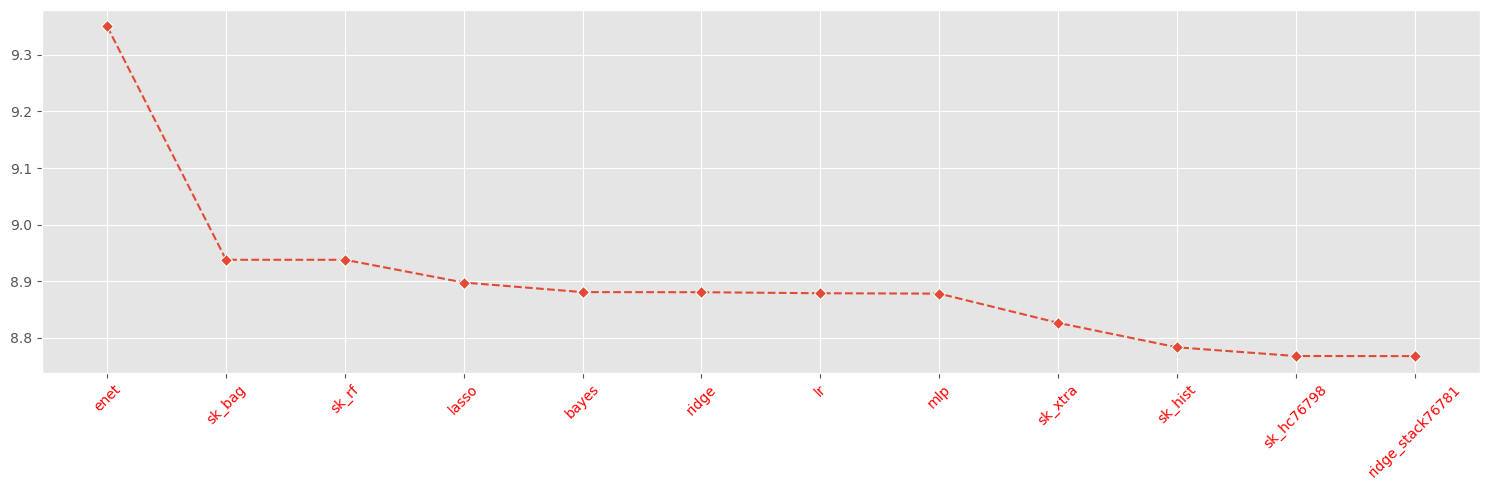

In [39]:
plt.figure(figsize=(15, 5))
sns.lineplot(model_score.sort_values(ascending=False), marker='D', ls='--')
plt.tick_params(axis='x', labelcolor='r', rotation=45)
plt.tight_layout()
plt.show()

In [40]:
oof_final.head(3)

,lr,enet,lasso,bayes,ridge,mlp,sk_rf,sk_bag,sk_xtra,sk_hist,ridge_stack76781,sk_hc76798
0,83.312279,85.075772,84.212067,83.523953,83.423709,83.244676,85.317,85.465,85.297257,84.435356,85.034216,85.093428
1,65.110050,66.975932,64.214804,64.905035,64.886770,65.592755,62.030,61.918,64.661126,64.196881,63.930631,63.771228
2,76.254658,73.886855,75.956987,76.091460,76.090965,75.387879,78.688,79.043,77.236164,75.761183,75.928967,75.931758


In [41]:
test_final.head(3)

,lr,enet,lasso,bayes,ridge,mlp,sk_rf,sk_bag,sk_xtra,sk_hist,ridge_stack76781,sk_hc76798
0,72.621347,71.845788,71.691673,72.481236,72.523419,72.149569,71.86775,71.850500,71.658533,72.119527,71.906423,71.864230
1,70.027326,68.576068,69.396963,69.985177,70.001334,70.393754,71.55525,71.674250,70.727488,70.171936,70.525372,70.498294
2,87.425409,86.618245,87.393975,87.452306,87.464453,87.050970,84.87925,84.973625,85.667439,87.823973,87.477449,87.554938


# SAVE FILES

In [42]:
## -- Export OOF & TEST predictions for each model --
n = 'sk_hc-stack.parquet'

oof_final.iloc[:, -2:].to_parquet(f"oof_{n}", index=False)
test_final.iloc[:, -2:].to_parquet(f"pred_{n}", index=False)

print('oof & test files saved!', n)

oof & test files saved! sk_hc-stack.parquet
